In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum, Domain
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration

# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

# domain charactrization

# background subtraction
from pyspectrum.background.snip import SNIPBackground
from pyspectrum.background.minimum_in_envolope import MinimaEnvelopeBackground
from pyspectrum.background.polynomial import IterativePolyFit, IterativePolyFitWithMinimum
from pyspectrum.background.als import ALSBackground

from pyspectrum.domain_analysis.background import domain_erf_background, domain_linear_background

# load the spectrum

In [2]:
path = '../Library/Doppler_broadening_Spectrum.txt'
df_spectrum = pd.read_csv(path, sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])


# known calibration
energy_calib_poly = np.poly1d([0.0408976444, 0.0822321508])
# known resolution
energy_resolution = 1.05
estimated_FWHM = StandardHPGeFWHMModel().generator((0, energy_resolution/511**0.5, 0))

energy_calib = AxisCalibration(func=energy_calib_poly, name="energy")
res_calib = ResolutionCalibration(func=estimated_FWHM)

spectrum  = TimeChannelParser.from_file(path, energy_calibration=energy_calib, fwhm_calibration=res_calib,
                                        num_of_channels=16384, chunk_size=int(10000),
                                        sep=' ', skiprows=5, names=['time','channel','flag'], usecols=[0,1,2])

In [3]:
energy_calib_poly(7000)

286.3657429508

In [4]:
i_start = 8000
i_stop = len(spectrum.axis)-500
new_spec = Spectrum(
    counts=spectrum.counts[i_start:i_stop],
    channels=spectrum.channels[i_start:i_stop]-i_start,
    axis_calib=AxisCalibration(func=energy_calib_poly-energy_calib_poly(0)+energy_calib_poly(i_start), name="energy"),
    resolution_calib=spectrum.resolution_calib
)

In [5]:
conv = Convolution(resolution=res_calib.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=5, n_sigma_bg_threshold=2.5, persistence_factor=0.5)
domains = finder.find(new_spec)
domain = domains[2]

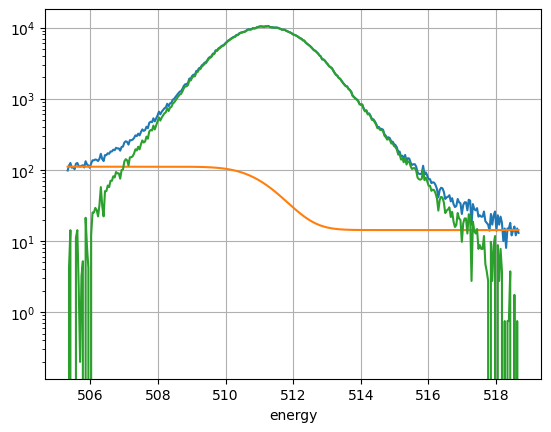

In [12]:
domain.plot(yscale='log')
plt.plot(domain.data.energy, domain_erf_background(domain))
plt.plot(domain.data.energy, domain-domain_erf_background(domain))
plt.grid()

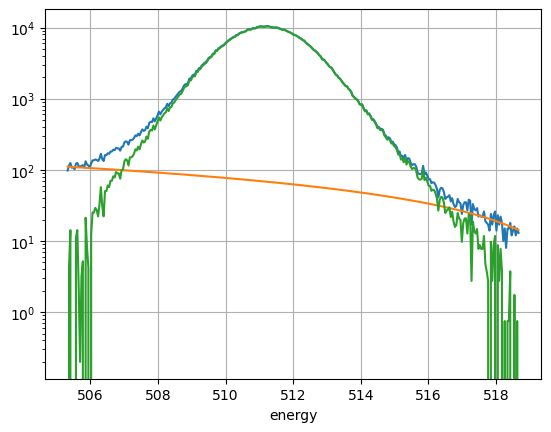

In [14]:
domain.plot(yscale='log')
plt.plot(domain.data.energy, domain_linear_background(domain))
plt.plot(domain.data.energy, domain-domain_erf_background(domain))
plt.grid()

In [ ]:
new_spec.plot(yscale='log')
for domain in domains:
    domain.plot(color='red')
plt.xlim([300, 700])
plt.grid(True, which='both')
plt.title('Annihilation spectrum and identified peaks')
plt.xlabel('Energy [keV]')
plt.ylabel('counts')

In [ ]:
spectrum.plot(yscale='log')
new_spec.plot(yscale='log')

# Global Background Estimation Methods

## SNIP background subtraction

In [78]:
snip_bg = SNIPBackground(50)
bg_estimation = snip_bg.estimate(axis=new_spec.axis, counts=new_spec.counts, resolution=new_spec.resolution_calib.apply, smoothing=True)

In [79]:
subtracted_spectrum = new_spec-bg_estimation
subtracted_spectrum.counts[subtracted_spectrum.counts < 0] = 0

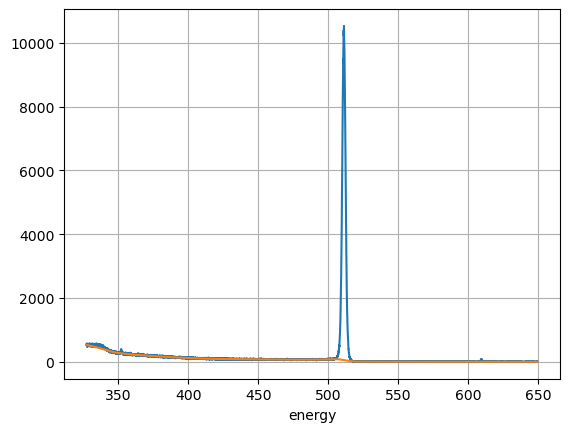

In [25]:
new_spec.plot(yscale='linear')
#subtracted_spectrum.plot()
plt.plot(new_spec.axis, bg_estimation)

plt.grid(True, which='both')
#plt.xlim([300,700])

# Minimum in Envelope method

In [26]:
me_bg = MinimaEnvelopeBackground(window_scale=5.0, snr_threshold=4.0)
me_bg_estimation = me_bg.estimate(axis=new_spec.axis,
                               counts=new_spec.counts,
                               resolution_calib=new_spec.resolution_calib,
                               conv=conv,
                              iterations=5)

C:\Users\ahiaa\AppData\Local\Temp\ipykernel_21260\658415770.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


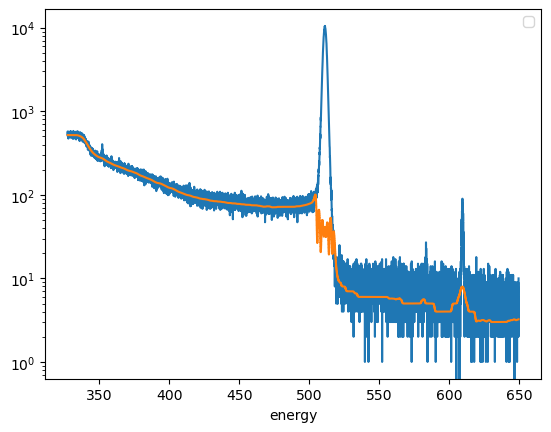

In [27]:
new_spec.plot(yscale='log')
plt.step(new_spec.axis, me_bg_estimation)

plt.legend()

C:\Users\ahiaa\AppData\Local\Temp\ipykernel_21260\1479112338.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


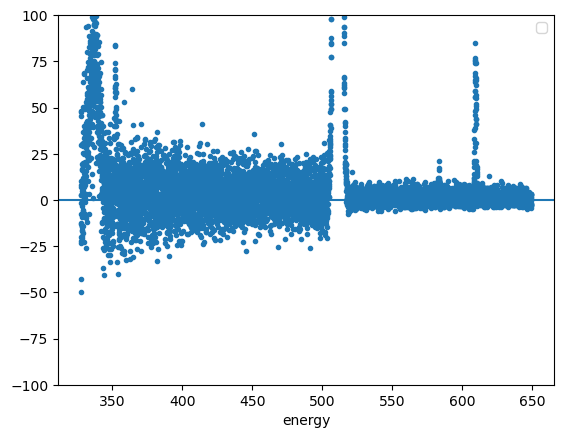

In [80]:
(new_spec-bg_estimation).plot(yscale='linear', marker='.', ls='')
plt.axhline(0)

plt.ylim([-100, 100])
plt.legend()

In [105]:
from scipy.signal import find_peaks

peaks, properties = find_peaks(new_spec.values, prominence=100, width)

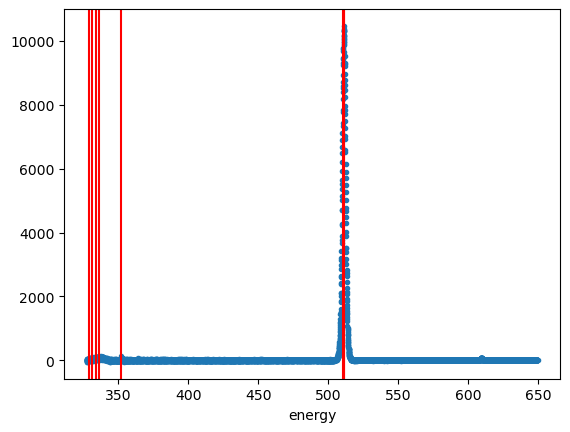

In [106]:
(new_spec-bg_estimation).plot(yscale='linear', marker='.', ls='')

for peak in peaks:
    plt.axvline(new_spec.axis[peak], color='red')


In [107]:
peaks

array([  46,  100,  169,  221,  604, 4485, 4493, 4499], dtype=int64)

In [84]:
t = (new_spec-bg_estimation)
t.sel(energy=slice(360,450)).sum()

<xarray.DataArray ()>
array(6459.93992823)

## Polynomial method

In [28]:
est = IterativePolyFit(degree=6, max_iter=25, tolerance=0.001)
poly_bg = est.estimate(new_spec.axis, new_spec.counts)

C:\Users\ahiaa\AppData\Local\Temp\ipykernel_21260\2799196552.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


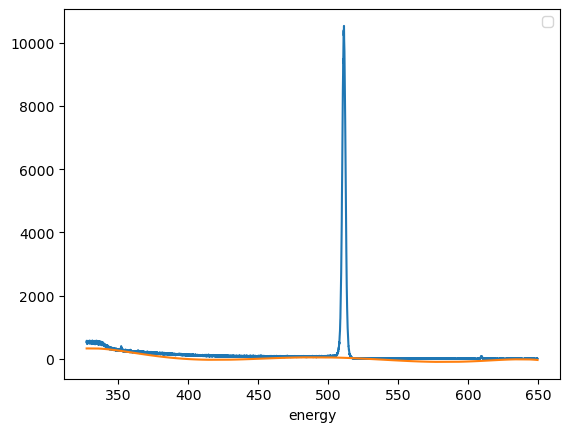

In [29]:
new_spec.plot(yscale='linear')
plt.step(new_spec.axis, poly_bg)

plt.legend()

## Polynomial method with minimum 

In [49]:
est = IterativePolyFitWithMinimum(degree=5,max_iter=100,tolerance=1e-3,window_scale=5.0,snr_threshold=4.0,)
poly_with_min_bg = est.estimate(new_spec.axis, new_spec.counts, new_spec.resolution_calib, conv)

C:\Users\ahiaa\AppData\Local\Temp\ipykernel_21260\456525280.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


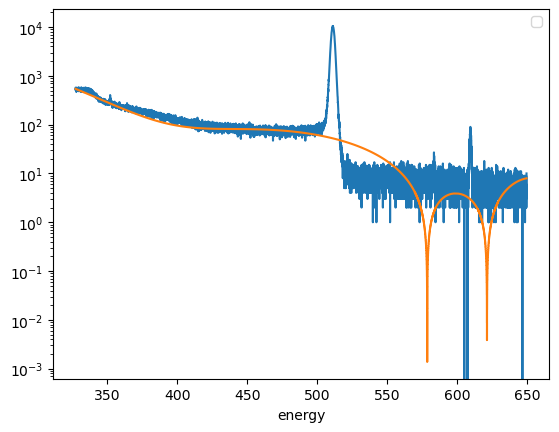

In [50]:
new_spec.plot(yscale='log')
plt.step(new_spec.axis, np.abs(poly_with_min_bg))

plt.legend()

## ALS

In [53]:
est = ALSBackground(lam=1e5, p=0.001, max_iter=50)
als_bg = est.estimate(new_spec.axis, new_spec.counts)

C:\Users\ahiaa\AppData\Local\Temp\ipykernel_21260\3341980776.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


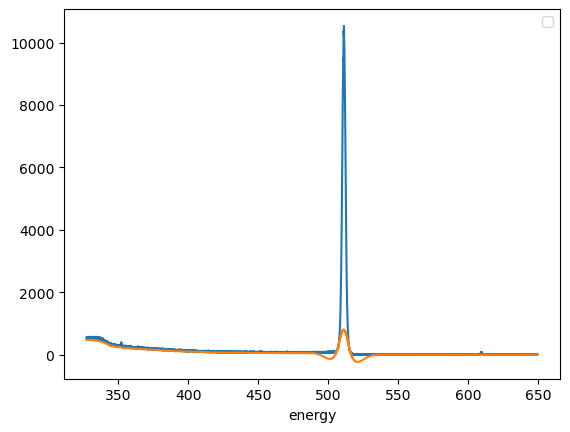

In [54]:
new_spec.plot(yscale='linear')
plt.step(new_spec.axis, als_bg)

plt.legend()

# Domain Background

In [12]:
subtracted_annihilation_domain = Domain(subtracted_spectrum, start=domain.start, stop=domain.stop)

The annihilation peak